CUstomers length: 100, n_dyn: 20, dynamic_ids: [4, 14, 18, 21, 27, 30, 34, 40, 45, 52, 57, 59, 68, 69, 76, 89, 92, 97, 98, 100]
service_start: 16293, c.due_time: 15500.0, completion_time: 17293, lateness: 793.0
Customer 14 is late.
{'unserved': 0.0, 'late_count': 1.0, 'late_sum': 793.0, 'capacity': 0.0}
CUstomers length: 100, n_dyn: 20, dynamic_ids: [4, 14, 18, 21, 27, 30, 34, 40, 45, 52, 57, 59, 68, 69, 76, 89, 92, 97, 98, 100]
{'unserved': 1.0, 'late_count': 0.0, 'late_sum': 0.0, 'capacity': 0.0}
CUstomers length: 100, n_dyn: 20, dynamic_ids: [4, 14, 18, 21, 27, 30, 34, 40, 45, 52, 57, 59, 68, 69, 76, 89, 92, 97, 98, 100]
service_start: 16293, c.due_time: 15500.0, completion_time: 17293, lateness: 793.0
Customer 14 is late.


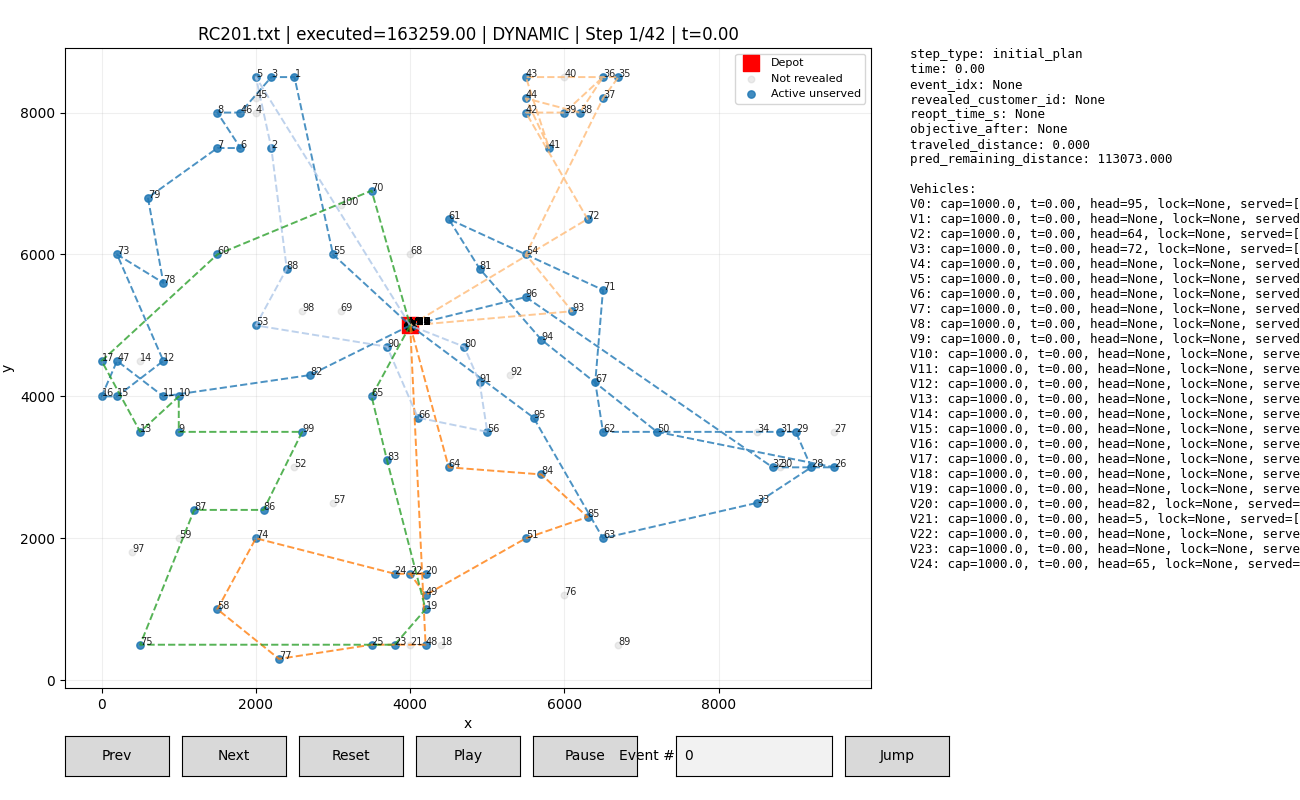

In [3]:
%matplotlib widget
from dvrptw_bench.dynamic.simulator import DynamicSimulator
from dvrptw_bench.viz.inspector import inspect_dynamic
from dvrptw_bench.heuristics.ortools_dynamic import ORToolsDVRPTWSolver

from pathlib import Path

from pyarrow import dataset

from dvrptw_bench.data.instance_filters import find_rc_instances
from dvrptw_bench.data.solomon_parser import parse_solomon

dataset_path = Path("../../dataset/solomon_rc100")
instances = [parse_solomon(instance, max_customers=100, distance_scale=100) for instance in find_rc_instances(dataset_path)]
dod = 0.2
cutoff = 0.9
budget_s = 0.1
# dynamic_instances = [build_dynamic_scenario(instance, epsilon=dod, seed=42) for instance in instances]

sim = DynamicSimulator(instances[0])
res = sim.run(lambda instance, time_limit_s, warm_start = None: ORToolsDVRPTWSolver(True).solve(instance, time_limit_s, warm_start), budget_s=budget_s, epsilon=dod, seed=15, cutoff_ratio=cutoff)
print(res[0].violations)
res = sim.run(lambda instance, time_limit_s, warm_start = None: ORToolsDVRPTWSolver(False).solve(instance, time_limit_s, warm_start), budget_s=budget_s, epsilon=dod, seed=15, cutoff_ratio=cutoff)
print(res[0].violations)
inspect_dynamic(instances[0], sim, lambda instance, time_limit_s, warm_start = None: ORToolsDVRPTWSolver().solve(instance, time_limit_s, warm_start), budget_s=budget_s, epsilon=dod, seed=15, cutoff_ratio=cutoff)


In [2]:
res[0].violations

{'unserved': 0.0, 'late_count': 0.0, 'late_sum': 0.0, 'capacity': 0.0}

In [3]:
%matplotlib widget
from dvrptw_bench.heuristics.ortools_solver import ORToolsVRPTWSolver
from dvrptw_bench.viz.inspector import inspect_static
ortoolsSolver = ORToolsVRPTWSolver()
sol = ortoolsSolver.solve(instances[0], time_limit_s=10)

# inspect_static(instances[0], sol)
# inspect_static(instances[0], ORToolsVRPTWSolver().solve(instances[0], time_limit_s=10))

(131074.0, 129654.0, 1420.0)